<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/Kalman/sds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install filterpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from filterpy.kalman import EnsembleKalmanFilter
from numpy.random import multivariate_normal, randn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=082cddfc67653f88b4fbb86ca63e133e665a314a4e18f501b973862e2e8d1070
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [5]:
df = pd.read_excel('/content/sample_data/SupplyDemandStorage.xlsx')

In [6]:
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')

In [7]:
observed_period_end = df['Supply'].dropna().index[-1]
observed_df = df.loc[:observed_period_end].copy()

Starting Data Assimilation (Training)...
Data Assimilation Complete.
Starting Forecast Phase...
Forecast Phase Complete.

--- ENKF Final Forecasted Values ---
            Supply_ENKF  Demand_ENKF  Storage_ENKF
Month                                             
2026-04-01  1752.167105  1808.693965   5540.565536
2026-05-01  1756.233803  1793.544158   5481.328243
2026-06-01  1758.928670  1781.360034   5422.090950
2026-07-01  1761.346304  1777.181067   5362.853657
2026-08-01  1763.507846  1783.733228   5303.616364


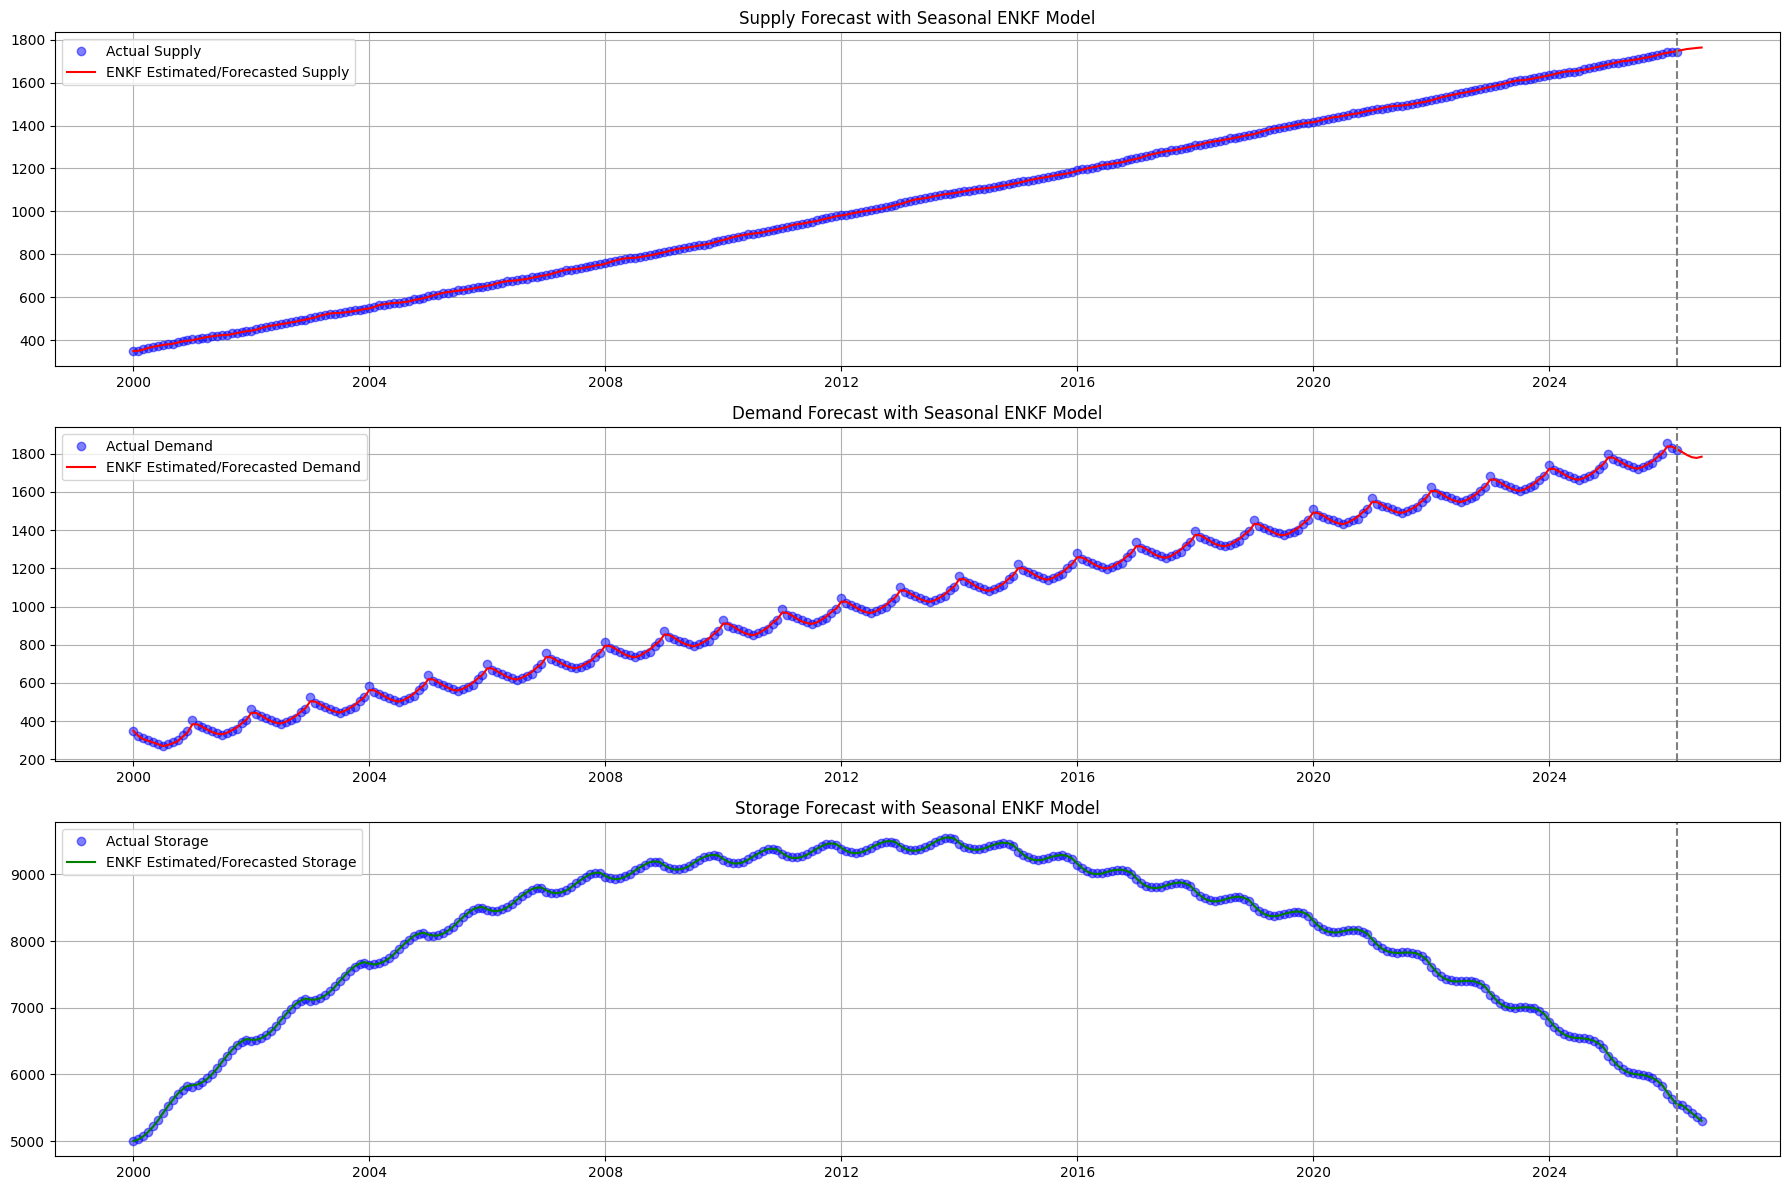

In [8]:
last_observed_full_data_date = df['Supply'].dropna().index[-1]
observed_df = df.loc[:last_observed_full_data_date].copy()
forecast_period_start = observed_df.index[-1] + pd.DateOffset(months=1)
forecast_df_template = df.loc[forecast_period_start:].copy()
training_data = observed_df[['Supply', 'Demand', 'Storage']].values
training_dates = observed_df.index
forecast_storage_values = forecast_df_template['Storage'].values
forecast_dates = forecast_df_template.index

# --- EnKF Model Setup with Augmented State for Seasonality ---
dim_x = 9  # Augmented State: [S_level, S_seas_cos, S_seas_sin, D_level, D_seas_cos, D_seas_sin, Storage, S_slope, D_slope]
dim_z = 3  # Measurement: [Supply, Demand, Storage]
N_ensemble = 500 # Larger ensemble for a more complex state

# --- Define State Transition Function (fx) for Augmented State ---
def fx(x, dt):
    # This function now evolves the level, slope, and seasonal components

    # Trigonometric rotation for seasonal components (12-month period)
    angle = 2 * np.pi / 12.0
    cos_a, sin_a = np.cos(angle), np.sin(angle)

    # Evolve Supply Components
    s_level = x[0] + x[7] # New level = old level + slope
    s_seas_cos = x[1] * cos_a + x[2] * sin_a
    s_seas_sin = -x[1] * sin_a + x[2] * cos_a
    s_slope = x[7] # Slope is a random walk

    # Evolve Demand Components
    d_level = x[3] + x[8] # New level = old level + slope
    d_seas_cos = x[4] * cos_a + x[5] * sin_a
    d_seas_sin = -x[4] * sin_a + x[5] * cos_a
    d_slope = x[8] # Slope is a random walk

    # Evolve Storage (based on the *total* supply and demand from PREVIOUS step)
    # Total Supply = Level + Seasonal
    prev_total_supply = x[0] + x[1]
    prev_total_demand = x[3] + x[4]
    storage = x[6] + (prev_total_supply - prev_total_demand)

    return np.array([
        s_level, s_seas_cos, s_seas_sin,
        d_level, d_seas_cos, d_seas_sin,
        storage,
        s_slope, d_slope
    ])

# --- Define Measurement Function (hx) for Augmented State ---
def hx(x):
    # Maps the 9-dim state to a 3-dim measurement
    # Observed Supply = Supply Level + Supply Seasonal Cos
    # Observed Demand = Demand Level + Demand Seasonal Cos
    # Observed Storage = Storage Level
    supply_obs = x[0] + x[1]
    demand_obs = x[3] + x[4]
    storage_obs = x[6]
    return np.array([supply_obs, demand_obs, storage_obs])


# --- Initialization ---
# Initial state: We have to guess the initial level, seasonal, and slope components
initial_state = np.zeros(dim_x)
initial_state[0] = training_data[0, 0] # Initial Supply Level
initial_state[3] = training_data[0, 1] # Initial Demand Level
initial_state[6] = training_data[0, 2] # Initial Storage Level
# Other components (seasonal, slope) start at zero

enkf = EnsembleKalmanFilter(
    x=initial_state,
    P=np.diag([50**2]*dim_x), # High initial uncertainty for all state components
    dim_z=dim_z,
    dt=1,
    N=N_ensemble,
    hx=hx,
    fx=fx
)

# Process and Measurement Noise for the Augmented State
enkf.Q = np.diag([
    10**2, 2**2, 2**2,   # S_level, S_seas, S_seas
    10**2, 2**2, 2**2,   # D_level, D_seas, D_seas
    20**2,              # Storage
    1**2, 1**2          # S_slope, D_slope
])
enkf.R = np.diag([20**2, 20**2, 30**2]) # Measurement noise remains the same

# --- Data Assimilation Phase (Training) ---
estimated_states = []
print("Starting Data Assimilation (Training)...")
for z in training_data:
    enkf.predict()
    enkf.update(z)
    estimated_states.append(enkf.x.copy()) # Store the mean of the augmented state
estimated_states = np.array(estimated_states)
print("Data Assimilation Complete.")

# --- Forecasting Phase with Manual State Correction ---
print("Starting Forecast Phase...")
forecasted_states_enkf = []
for i, date in enumerate(forecast_dates):
    # 1. Predict the state for the next time step using the augmented model
    enkf.predict()
    predicted_state = enkf.x.copy() # This is the 9-dim predicted state mean

    # 2. Get the known future value for Storage
    known_future_storage = forecast_storage_values[i]

    # 3. Manual Correction: Override the storage component of the state
    predicted_state[6] = known_future_storage # Index 6 is Storage

    # 4. Update the filter's state for the next iteration
    enkf.x = predicted_state

    forecasted_states_enkf.append(predicted_state)

forecasted_states_enkf = np.array(forecasted_states_enkf)
print("Forecast Phase Complete.")

# --- Post-processing and Plotting ---
all_states = np.vstack((estimated_states, forecasted_states_enkf))

# Reconstruct the observed variables from the full state
supply_reconstructed = all_states[:, 0] + all_states[:, 1] # S_level + S_seas_cos
demand_reconstructed = all_states[:, 3] + all_states[:, 4] # D_level + D_seas_cos
storage_reconstructed = all_states[:, 6]

df_enkf_results = pd.DataFrame({
    'Supply_ENKF': supply_reconstructed,
    'Demand_ENKF': demand_reconstructed,
    'Storage_ENKF': storage_reconstructed
}, index=df.index)

print("\n--- ENKF Final Forecasted Values ---")
print(df_enkf_results.loc[forecast_dates])

# Plotting
plt.figure(figsize=(18, 12))
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Supply'], 'o', label='Actual Supply', c='blue', alpha=0.5)
plt.plot(df_enkf_results.index, df_enkf_results['Supply_ENKF'], label='ENKF Estimated/Forecasted Supply', c='red')
plt.axvline(x=observed_period_end, color='gray', linestyle='--')
plt.title('Supply Forecast with Seasonal ENKF Model')
plt.legend(); plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(df.index, df['Demand'], 'o', label='Actual Demand', c='blue', alpha=0.5)
plt.plot(df_enkf_results.index, df_enkf_results['Demand_ENKF'], label='ENKF Estimated/Forecasted Demand', c='red')
plt.axvline(x=observed_period_end, color='gray', linestyle='--')
plt.title('Demand Forecast with Seasonal ENKF Model')
plt.legend(); plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(df.index, df['Storage'], 'o', label='Actual Storage', c='blue', alpha=0.5)
plt.plot(df_enkf_results.index, df_enkf_results['Storage_ENKF'], label='ENKF Estimated/Forecasted Storage', c='green')
plt.axvline(x=observed_period_end, color='gray', linestyle='--')
plt.title('Storage Forecast with Seasonal ENKF Model')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()